In [1]:
!pip install git+https://github.com/jacobgil/pytorch-grad-cam.git

  Cloning https://github.com/jacobgil/pytorch-grad-cam.git to /tmp/pip-req-build-syoa7_k1
  Running command git clone --filter=blob:none --quiet https://github.com/jacobgil/pytorch-grad-cam.git /tmp/pip-req-build-syoa7_k1
  Resolved https://github.com/jacobgil/pytorch-grad-cam.git to commit 781dbc0d16ffa95b6d18b96b7b829840a82d93d1
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of mkl-fft to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-random to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-umath to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━

In [2]:
!pip uninstall -y scipy scikit-learn numpy
!pip install scipy==1.11.4 scikit-learn==1.4.2 --quiet

Found existing installation: scipy 1.15.3
Uninstalling scipy-1.15.3:
  Successfully uninstalled scipy-1.15.3
Found existing installation: scikit-learn 1.2.2
Uninstalling scikit-learn-1.2.2:
  Successfully uninstalled scikit-learn-1.2.2
Found existing installation: numpy 2.2.6
Uninstalling numpy-2.2.6:
  Successfully uninstalled numpy-2.2.6
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 50.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 101.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 87.0 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storag

In [3]:
!pip install numpy==1.26.4 --force-reinstall

  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
datasets 4.1.1 requires pyarrow>=21.0.0, but you have pyarrow 19.0.1 which is incompatible.
onnx 1.18.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires google-auth==2.38.0, but you have google-auth 2.40.3 which is incompatible.
goo

Found 6 images. Missing: 0
✅ Target layer for Grad-CAM (VGGFace2-ResNet50): model.layer4[-1].conv3
🔍 Layer type: Conv2d
📊 Output channels: 2048
Processing: Autistic.112.jpg


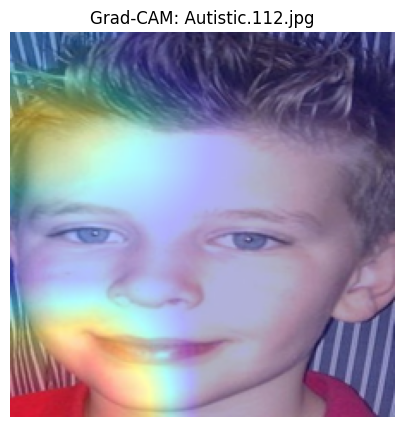

Processing: Autistic.30.jpg


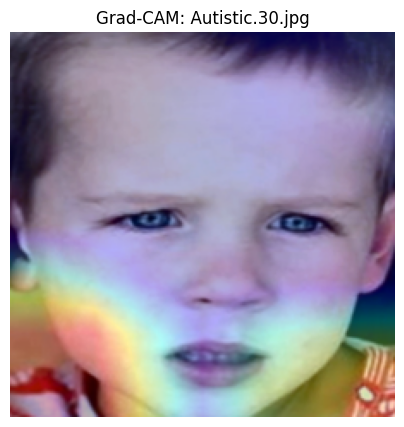

Processing: Autistic.81.jpg


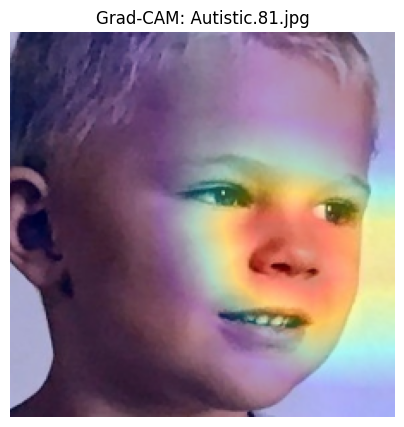

Processing: Non_Autistic.74.jpg


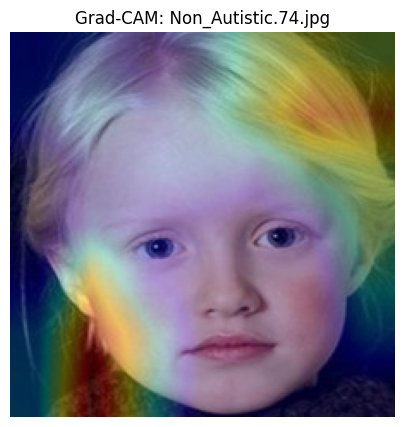

Processing: Non_Autistic.63.jpg


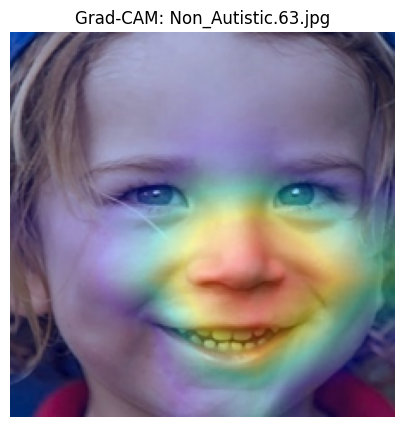

Processing: Non_Autistic.55.jpg


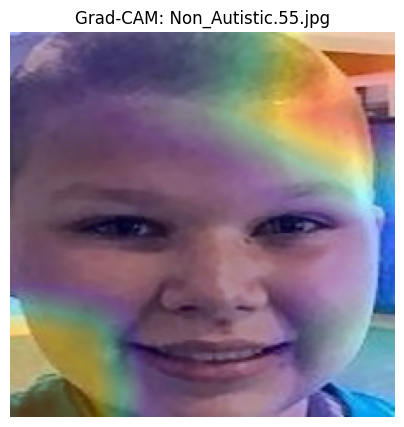

In [5]:
# gradcam_subset.py
# -----------------------------------------------------------
# Imports
import os, torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms, models
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image

# -----------------------------------------------------------
# Configuration
DATA_PATH = "/kaggle/input/autism-image-data/AutismDataset"
TEST_PATH = os.path.join(DATA_PATH, "test")

CKPT_PATH = "/kaggle/input/autism-spectrum-detection-from-kaggle-zenodo/Model results/Model results/best_vggface2_autism.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Explicit subset of test images
TARGET_FILES = [
    "Autistic.112.jpg",
    "Autistic.30.jpg",
    "Autistic.81.jpg",
    "Non_Autistic.74.jpg",
    "Non_Autistic.63.jpg",
    "Non_Autistic.55.jpg",
]

# -----------------------------------------------------------
# Validate selected images
selected_image_paths = []
missing = []
for fname in TARGET_FILES:
    candidate = os.path.join(TEST_PATH, fname)
    if os.path.exists(candidate):
        selected_image_paths.append(candidate)
    else:
        missing.append(fname)

print(f"Found {len(selected_image_paths)} images. Missing: {len(missing)}")
if missing:
    print("Missing files:", missing)

# -----------------------------------------------------------
# Preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# -----------------------------------------------------------
# Model Definition
import torch.nn as nn

def create_vggface2_model(num_classes=2, pretrained=True):
    """Create VGGFace2 model using ResNet50 backbone"""
    # Use ResNet50 as backbone (commonly used for VGGFace2)
    model = models.resnet50(pretrained=pretrained)
    
    # Modify for face recognition
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    
    return model

# -----------------------------------------------------------
# Load Model
model = create_vggface2_model(num_classes=2, pretrained=False).to(DEVICE)
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

def get_vggface2_target_layer(model):
    """
    Returns the target layer for GradCAM for the VGGFace2-ResNet50 model.
    It automatically detects and returns the final convolutional layer 
    in the last residual block (layer4.2.conv3).
    """
    try:
        # The ResNet50 backbone is directly in model
        # Last convolutional layer in the deepest residual block
        target_layer = model.layer4[-1].conv3
        print("✅ Target layer for Grad-CAM (VGGFace2-ResNet50): model.layer4[-1].conv3")
        print(f"🔍 Layer type: {type(target_layer).__name__}")
        if hasattr(target_layer, 'out_channels'):
            print(f"📊 Output channels: {target_layer.out_channels}")
        return target_layer
    except Exception as e:
        print(f"❌ Error locating target layer: {e}")
        return None

# -----------------------------------------------------------
# Grad-CAM Setup
target_layers = [get_vggface2_target_layer(model)]
cam = GradCAM(model=model, target_layers=target_layers)

# -----------------------------------------------------------
# Visualization Loop
for img_path in selected_image_paths:
    print(f"Processing: {os.path.basename(img_path)}")

    # Load image
    img_pil = Image.open(img_path).convert("RGB")
    rgb = np.array(img_pil.resize((224, 224))) / 255.0
    rgb = np.clip(rgb, 0, 1)

    # Preprocess for model
    input_tensor = transform(img_pil).unsqueeze(0).to(DEVICE)

    # Run Grad-CAM
    grayscale_cam = cam(input_tensor=input_tensor)[0]  # first image only

    # Overlay CAM
    visualization = show_cam_on_image(rgb.astype(np.float32),
                                      grayscale_cam,
                                      use_rgb=True,
                                      image_weight=0.7)

    # Plot
    plt.figure(figsize=(5, 5))
    plt.imshow(visualization)
    plt.title(f"Grad-CAM: {os.path.basename(img_path)}")
    plt.axis("off")
    plt.show()

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

🎯 Finding target layer for EfficientNet-B0...
✅ Found target layer: features.8.1
🔍 Layer type: BatchNorm2d
Processing: Autistic.112.jpg


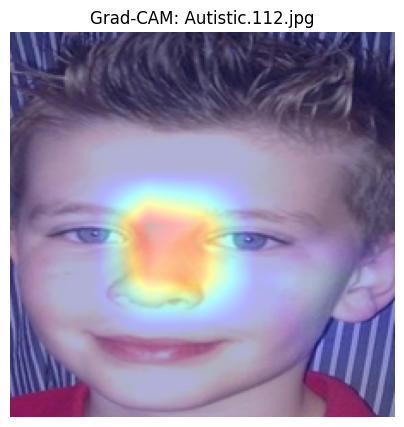

Processing: Autistic.30.jpg


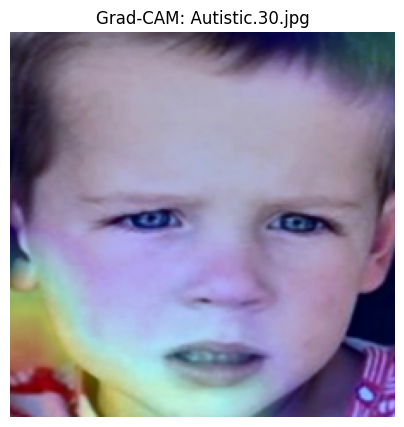

Processing: Autistic.81.jpg


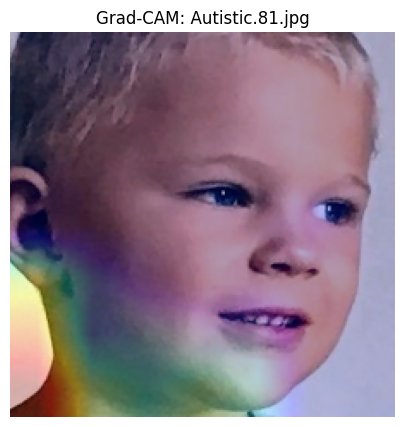

Processing: Non_Autistic.74.jpg


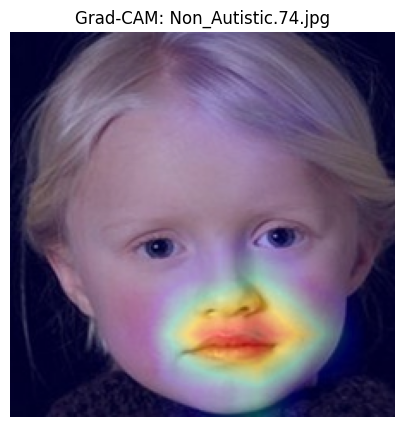

Processing: Non_Autistic.63.jpg


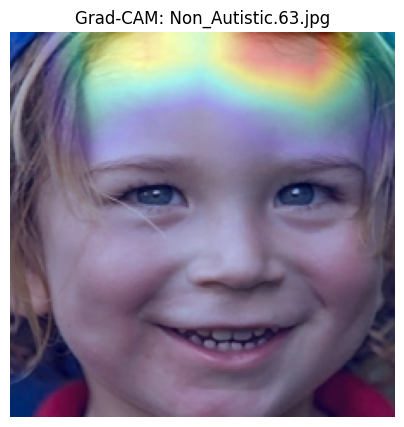

Processing: Non_Autistic.55.jpg


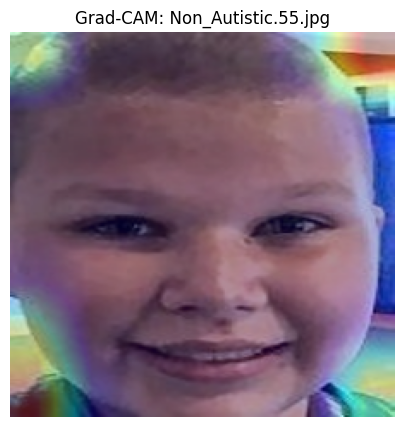

In [6]:
CKPT_PATH_2 = "/kaggle/input/autism-spectrum-detection-from-kaggle-zenodo/Model results/Model results/best_effnet-b0.pth"

# -----------------------------------------------------------
# Preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# -----------------------------------------------------------
# Model Definition
import torch.nn as nn
import timm

def create_efficientnet_model(architecture='b0', num_classes=2, pretrained=True):
    """Create EfficientNet model for binary classification"""
    if architecture == 'b0':
        model = models.efficientnet_b0(pretrained=pretrained)
    elif architecture == 'b1':
        model = models.efficientnet_b1(pretrained=pretrained)
    elif architecture == 'b2':
        model = models.efficientnet_b2(pretrained=pretrained)
    else:
        raise ValueError("Architecture must be 'b0', 'b1', or 'b2'")
    
    # Modify classifier
    num_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_features, num_classes)
    
    return model

# -----------------------------------------------------------
# Load Model
model = create_efficientnet_model(architecture='b0', num_classes=2, pretrained=False).to(DEVICE)
model.load_state_dict(torch.load(CKPT_PATH_2, map_location=DEVICE))
model.eval()

def get_efficientnet_b0_target_layer(model):
    """
    Get the target layer for GradCAM - for EfficientNet-B0
    """
    print(f"🎯 Finding target layer for EfficientNet-B0...")
    
    target_layer = None
    
    try:
        # For EfficientNet-B0, find the last convolutional layer in features
        for name, module in model.named_modules():
            if isinstance(module, (nn.Conv2d, nn.BatchNorm2d)):
                target_layer = module
                last_conv_name = name
        
        if target_layer is not None:
            print(f"✅ Found target layer: {last_conv_name}")
            print(f"🔍 Layer type: {type(target_layer).__name__}")
            if hasattr(target_layer, 'out_channels'):
                print(f"📊 Output channels: {target_layer.out_channels}")
        else:
            print("❌ No suitable target layer found")
    
    except Exception as e:
        print(f"❌ Error finding target layer: {e}")
        target_layer = None
    
    return target_layer

# -----------------------------------------------------------
# Grad-CAM Setup
target_layers = [get_efficientnet_b0_target_layer(model)]
cam = GradCAM(model=model, target_layers=target_layers)

# -----------------------------------------------------------
# Visualization Loop
for img_path in selected_image_paths:
    print(f"Processing: {os.path.basename(img_path)}")

    # Load image
    img_pil = Image.open(img_path).convert("RGB")
    rgb = np.array(img_pil.resize((224, 224))) / 255.0
    rgb = np.clip(rgb, 0, 1)

    # Preprocess for model
    input_tensor = transform(img_pil).unsqueeze(0).to(DEVICE)

    # Run Grad-CAM
    grayscale_cam = cam(input_tensor=input_tensor)[0]  # first image only

    # Overlay CAM
    visualization = show_cam_on_image(rgb.astype(np.float32),
                                      grayscale_cam,
                                      use_rgb=True,
                                      image_weight=0.7)

    # Plot
    plt.figure(figsize=(5, 5))
    plt.imshow(visualization)
    plt.title(f"Grad-CAM: {os.path.basename(img_path)}")
    plt.axis("off")
    plt.show()

✅ Target layer for Grad-CAM (ConvNeXt): model.stages[-1].blocks[-1].conv_dw
🔍 Layer type: Conv2d
📊 Output channels: 1024
Conv2d(1024, 1024, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=1024)
Processing: Autistic.112.jpg


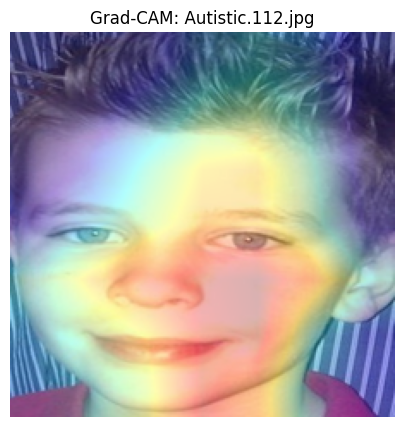

Processing: Autistic.30.jpg


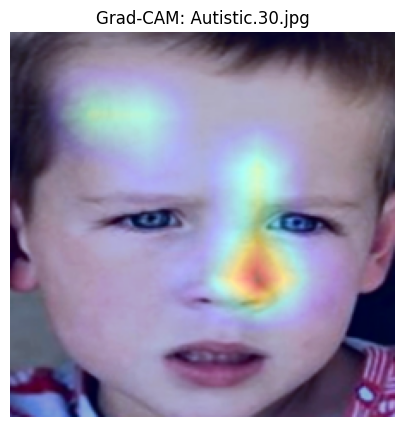

Processing: Autistic.81.jpg


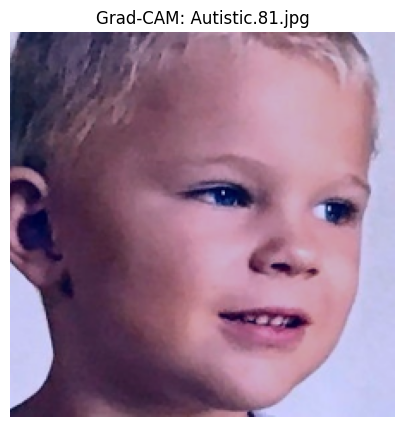

Processing: Non_Autistic.74.jpg


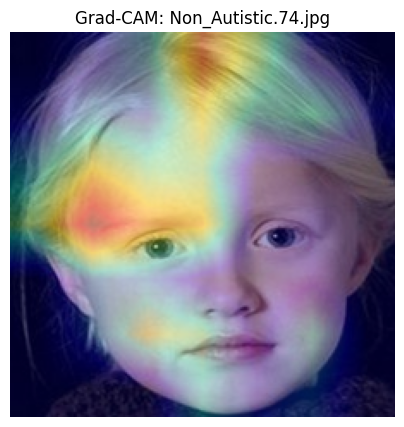

Processing: Non_Autistic.63.jpg


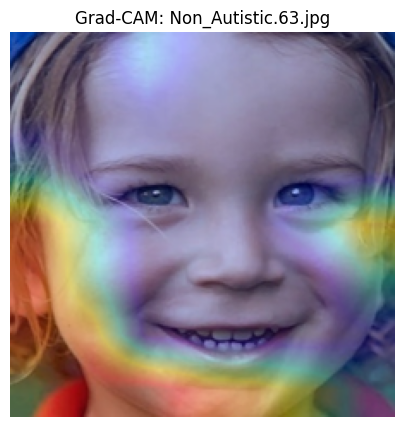

Processing: Non_Autistic.55.jpg


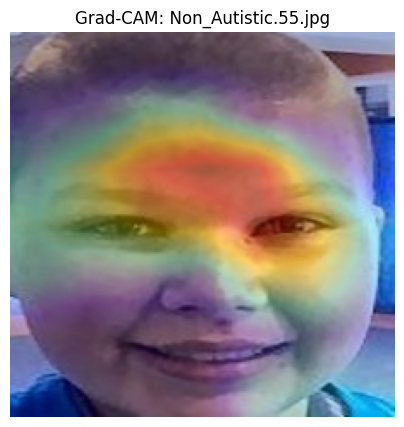

In [9]:
CKPT_PATH_3 = "/kaggle/input/autism-spectrum-detection-from-kaggle-zenodo/Model results/Model results/best_convnext_base_autism.pth"

# -----------------------------------------------------------
# Preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# -----------------------------------------------------------
# Model Definition
import torch.nn as nn
import timm

def create_convnext_model(architecture='convnext_tiny', num_classes=2, pretrained=True):
    """Create ConvNeXt model for binary classification"""
    if architecture == 'convnext_tiny':
        model = timm.create_model('convnext_tiny', pretrained=pretrained, num_classes=num_classes)
    elif architecture == 'convnext_small':
        model = timm.create_model('convnext_small', pretrained=pretrained, num_classes=num_classes)
    elif architecture == 'convnext_base':
        model = timm.create_model('convnext_base', pretrained=pretrained, num_classes=num_classes)
    else:
        raise ValueError("Architecture must be 'convnext_tiny', 'convnext_small', or 'convnext_base'")
    
    return model

# -----------------------------------------------------------
# Load Model
model = create_convnext_model(architecture='convnext_base', num_classes=2, pretrained=False).to(DEVICE)
model.load_state_dict(torch.load(CKPT_PATH_3, map_location=DEVICE))
model.eval()

def get_convnext_target_layer(model):
    """
    Returns the target layer for GradCAM for ConvNeXt models (tiny, small, base, large)
    compatible with both old and new timm versions.
    """
    try:
        # Get last ConvNeXt block from last stage
        last_block = model.stages[-1].blocks[-1]

        # Handle version differences
        if hasattr(last_block, "dwconv"):   # Newer TIMM
            target_layer = last_block.dwconv
            layer_name = "dwconv"
        elif hasattr(last_block, "conv_dw"):  # Older TIMM
            target_layer = last_block.conv_dw
            layer_name = "conv_dw"
        else:
            raise AttributeError("Neither 'dwconv' nor 'conv_dw' found in ConvNeXtBlock")

        print(f"✅ Target layer for Grad-CAM (ConvNeXt): model.stages[-1].blocks[-1].{layer_name}")
        print(f"🔍 Layer type: {type(target_layer).__name__}")
        if hasattr(target_layer, "out_channels"):
            print(f"📊 Output channels: {target_layer.out_channels}")
        return target_layer

    except Exception as e:
        print(f"❌ Error locating target layer: {e}")
        return None

target_layer = get_convnext_target_layer(model)
print(target_layer)

# -----------------------------------------------------------
# Grad-CAM Setup
target_layers = [target_layer]
cam = GradCAM(model=model, target_layers=target_layers)

# -----------------------------------------------------------
# Visualization Loop
for img_path in selected_image_paths:
    print(f"Processing: {os.path.basename(img_path)}")

    # Load image
    img_pil = Image.open(img_path).convert("RGB")
    rgb = np.array(img_pil.resize((224, 224))) / 255.0
    rgb = np.clip(rgb, 0, 1)

    # Preprocess for model
    input_tensor = transform(img_pil).unsqueeze(0).to(DEVICE)

    # Run Grad-CAM
    grayscale_cam = cam(input_tensor=input_tensor)[0]  # first image only

    # Overlay CAM
    visualization = show_cam_on_image(rgb.astype(np.float32),
                                      grayscale_cam,
                                      use_rgb=True,
                                      image_weight=0.7)

    # Plot
    plt.figure(figsize=(5, 5))
    plt.imshow(visualization)
    plt.title(f"Grad-CAM: {os.path.basename(img_path)}")
    plt.axis("off")
    plt.show()

✅ Target layer for Grad-CAM (DenseNet121): model.features.denseblock4[-1].conv2
🔍 Layer type: Conv2d
Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
Processing: Autistic.112.jpg


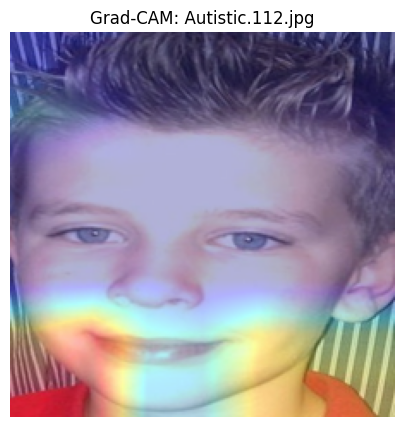

Processing: Autistic.30.jpg


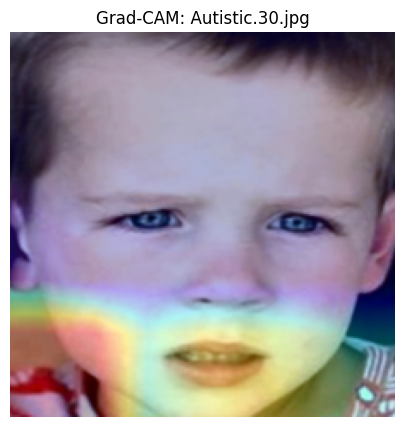

Processing: Autistic.81.jpg


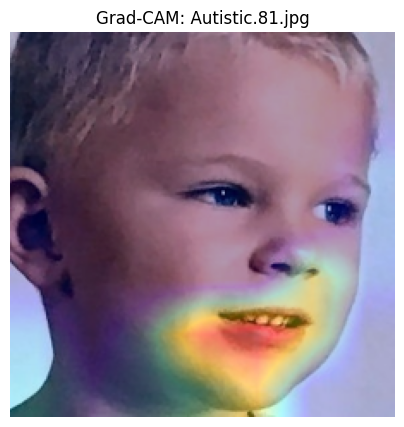

Processing: Non_Autistic.74.jpg


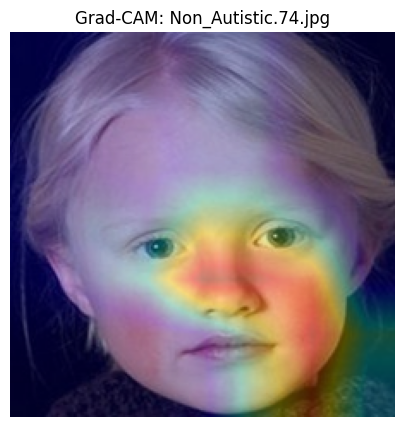

Processing: Non_Autistic.63.jpg


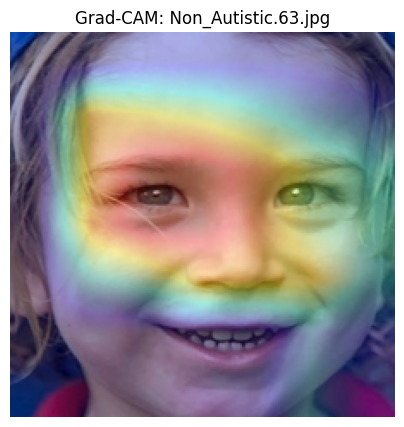

Processing: Non_Autistic.55.jpg


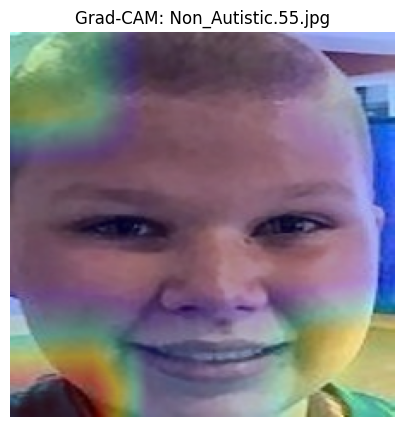

In [11]:
CKPT_PATH_4 = "/kaggle/input/autism-spectrum-detection-from-kaggle-zenodo/Model results/Model results/best_densenet121.pth"

# -----------------------------------------------------------
# Preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),  
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

# -----------------------------------------------------------
# Model Definition
import torch.nn as nn

def create_densenet_model(architecture='121', num_classes=2, pretrained=True):
    """Create DenseNet model (121 or 169) for binary classification"""
    if architecture == '121':
        model = models.densenet121(pretrained=pretrained)
    elif architecture == '169':
        model = models.densenet169(pretrained=pretrained)
    else:
        raise ValueError("Architecture must be '121' or '169'")
    
    # Modify classifier
    num_features = model.classifier.in_features
    model.classifier = nn.Linear(num_features, num_classes)
    
    return model

# -----------------------------------------------------------
# Load Model
model = create_densenet_model(architecture='121', num_classes=2, pretrained=False).to(DEVICE)
model.load_state_dict(torch.load(CKPT_PATH_4, map_location=DEVICE))
model.eval()

def get_densenet121_target_layer(model):
    """
    Returns the final convolutional layer for Grad-CAM from DenseNet121.
    Works for torchvision and timm variants.
    """
    try:
        # Torchvision & TIMM both use `features` sequential container
        features = model.features if hasattr(model, "features") else model
        
        # Get the last dense block (usually denseblock4)
        dense_blocks = [m for n, m in features.named_children() if "denseblock" in n.lower()]
        if not dense_blocks:
            raise AttributeError("No dense blocks found in model.features")
        last_block = dense_blocks[-1]
        
        # Get all DenseLayer modules inside last block
        dense_layers = [m for m in last_block.children()]
        if not dense_layers:
            raise AttributeError("No dense layers found in final dense block")
        last_layer = dense_layers[-1]
        
        # Inside DenseLayer, conv2 is the final 3x3 convolution
        if hasattr(last_layer, "conv2"):
            target_layer = last_layer.conv2
            print("✅ Target layer for Grad-CAM (DenseNet121): model.features.denseblock4[-1].conv2")
            print(f"🔍 Layer type: {type(target_layer).__name__}")
            return target_layer
        else:
            raise AttributeError("DenseLayer does not contain conv2")
            
    except Exception as e:
        print(f"❌ Error locating target layer: {e}")
        return None

target_layer = get_densenet121_target_layer(model)
print(target_layer)

# -----------------------------------------------------------
# Grad-CAM Setup
target_layers = [target_layer]
cam = GradCAM(model=model, target_layers=target_layers)

# -----------------------------------------------------------
# Visualization Loop
for img_path in selected_image_paths:
    print(f"Processing: {os.path.basename(img_path)}")

    # Load image
    img_pil = Image.open(img_path).convert("RGB")
    rgb = np.array(img_pil.resize((224, 224))) / 255.0
    rgb = np.clip(rgb, 0, 1)

    # Preprocess for model
    input_tensor = transform(img_pil).unsqueeze(0).to(DEVICE)

    # Run Grad-CAM
    grayscale_cam = cam(input_tensor=input_tensor)[0]  # first image only

    # Overlay CAM
    visualization = show_cam_on_image(rgb.astype(np.float32),
                                      grayscale_cam,
                                      use_rgb=True,
                                      image_weight=0.7)

    # Plot
    plt.figure(figsize=(5, 5))
    plt.imshow(visualization)
    plt.title(f"Grad-CAM: {os.path.basename(img_path)}")
    plt.axis("off")
    plt.show()

✅ Target layer for Grad-CAM (InsightFace ResNet50): model.backbone[7][-1].conv3
🔍 Layer type: Conv2d
Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
Processing: Autistic.112.jpg


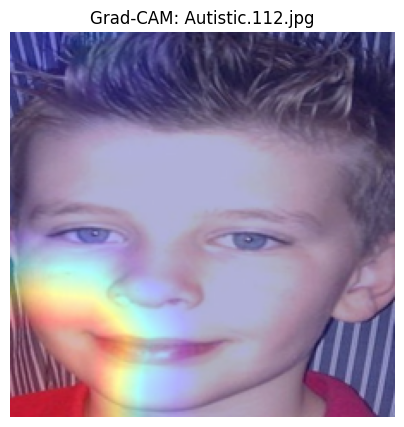

Processing: Autistic.30.jpg


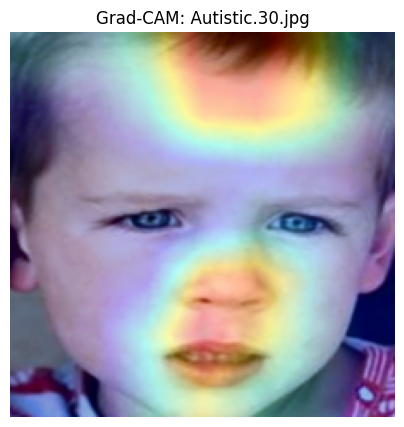

Processing: Autistic.81.jpg


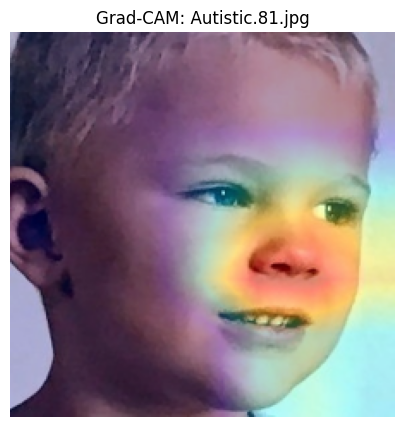

Processing: Non_Autistic.74.jpg


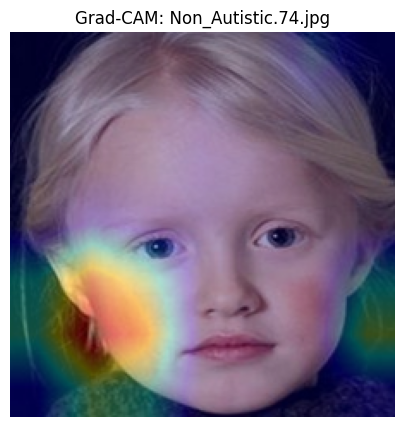

Processing: Non_Autistic.63.jpg


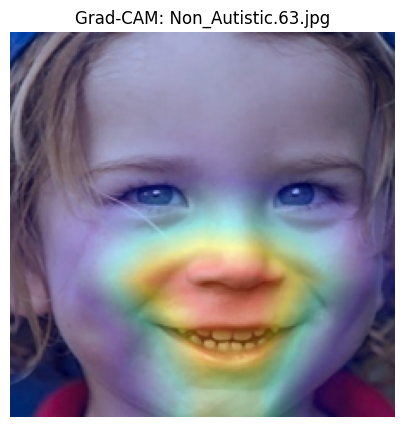

Processing: Non_Autistic.55.jpg


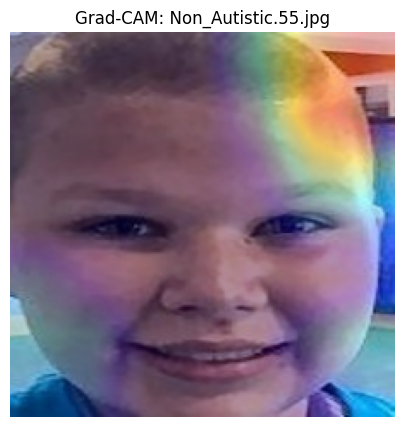

In [13]:
CKPT_PATH_5 = "/kaggle/input/autism-spectrum-detection-from-kaggle-zenodo/Model results/Model results/best_insightface_autism.pth"

# -----------------------------------------------------------
# Preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),  
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

# -----------------------------------------------------------
# Model Definition
import torch.nn as nn

def create_insightface_model(num_classes=2, pretrained=True, embedding_size=512):
    """Create InsightFace-style model with deep supervision"""
    base_model = models.resnet50(pretrained=pretrained)
    
    class InsightFaceModel(nn.Module):
        def __init__(self, base_model, embedding_size, num_classes):
            super(InsightFaceModel, self).__init__()
            self.backbone = nn.Sequential(*list(base_model.children())[:-1])
            self.flatten = nn.Flatten()
            self.bn1 = nn.BatchNorm1d(2048)
            self.dropout = nn.Dropout(0.5)
            self.fc1 = nn.Linear(2048, embedding_size)
            self.bn2 = nn.BatchNorm1d(embedding_size)
            self.fc2 = nn.Linear(embedding_size, num_classes)
            
        def forward(self, x):
            x = self.backbone(x)
            x = self.flatten(x)
            x = self.bn1(x)
            x = self.dropout(x)
            embeddings = self.fc1(x)
            embeddings = self.bn2(embeddings)
            output = self.fc2(embeddings)
            return output
    
    return InsightFaceModel(base_model, embedding_size, num_classes)

# -----------------------------------------------------------
# Load Model
model = create_insightface_model(num_classes=2, pretrained=False).to(DEVICE)
model.load_state_dict(torch.load(CKPT_PATH_5, map_location=DEVICE))
model.eval()

def get_insightface_target_layer(model):
    """
    Get target layer for Grad-CAM in the custom InsightFace model.
    Focuses on the last convolution inside layer4 of ResNet50 backbone.
    """
    try:
        # Access the ResNet backbone
        backbone = model.backbone
        
        # layer4 is at index 7 in the sequential backbone
        layer4 = backbone[7]
        
        # Get last Bottleneck block in layer4
        last_block = list(layer4.children())[-1]
        
        # Each Bottleneck block has a 'conv3' as the final conv layer
        if hasattr(last_block, "conv3"):
            target_layer = last_block.conv3
            print("✅ Target layer for Grad-CAM (InsightFace ResNet50): model.backbone[7][-1].conv3")
            print(f"🔍 Layer type: {type(target_layer).__name__}")
            return target_layer
        else:
            raise AttributeError("No conv3 found in final bottleneck block.")
            
    except Exception as e:
        print(f"❌ Error locating target layer: {e}")
        return None

target_layer = get_insightface_target_layer(model)
print(target_layer)

# -----------------------------------------------------------
# Grad-CAM Setup
target_layers = [target_layer]
cam = GradCAM(model=model, target_layers=target_layers)

# -----------------------------------------------------------
# Visualization Loop
for img_path in selected_image_paths:
    print(f"Processing: {os.path.basename(img_path)}")

    # Load image
    img_pil = Image.open(img_path).convert("RGB")
    rgb = np.array(img_pil.resize((224, 224))) / 255.0
    rgb = np.clip(rgb, 0, 1)

    # Preprocess for model
    input_tensor = transform(img_pil).unsqueeze(0).to(DEVICE)

    # Run Grad-CAM
    grayscale_cam = cam(input_tensor=input_tensor)[0]  # first image only

    # Overlay CAM
    visualization = show_cam_on_image(rgb.astype(np.float32),
                                      grayscale_cam,
                                      use_rgb=True,
                                      image_weight=0.7)

    # Plot
    plt.figure(figsize=(5, 5))
    plt.imshow(visualization)
    plt.title(f"Grad-CAM: {os.path.basename(img_path)}")
    plt.axis("off")
    plt.show()